# 03 — Training

Current champion from `models/_pointer.json`: test metrics vs the baseline, calibration curve and feature importance (from its MLflow run). No row data is shown. Needs the local stack (`make up`).

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Settings read `.env` from the working directory: run from the repo root.
if Path.cwd().name == "notebooks":
    os.chdir("..")

from dbdelay.config import get_settings
from dbdelay.registry.artifacts import load_bundle
from dbdelay.registry.pointer import ObjectStorePointer
from dbdelay.storage import ObjectStore, make_s3_client
from dbdelay.training.evaluate import TrainingReport
from dbdelay.training.tracking import MlflowTracker

settings = get_settings()
store = ObjectStore(make_s3_client(settings), settings.models_bucket)
version = ObjectStorePointer(store).get().champion_version
bundle = load_bundle(store, version)
run_id = bundle.manifest.mlflow_run_id
tracker = MlflowTracker(settings.mlflow_tracking_uri)
report = TrainingReport.model_validate_json(tracker.load_bytes(run_id, "bundle/metrics.json"))
version, report.snapshot_id

('1', '2026-08-31_38b45c7a')

In [2]:
rows = {"challenger": report.challenger_test, "baseline": report.baseline_test}
if report.champion_test is not None:
    rows["previous champion"] = report.champion_test
pd.DataFrame({k: v.overall.model_dump() for k, v in rows.items()}).round(4)

,challenger,baseline
n,176628.0000,176628.0000
base_rate,0.2473,0.2473
brier,0.1408,0.1520
roc_auc,0.8078,0.7714
pr_auc,0.5959,0.5272
log_loss,0.4391,0.4704
ece,0.0218,0.0124


In [3]:
slices = {
    name: {k: m.roc_auc for k, m in split.slices["train_type"].items()}
    for name, split in rows.items()
}
pd.DataFrame(slices).round(4)

,challenger,baseline
ABR,0.7068,0.6221
AG,NaN,NaN
ALX,NaN,NaN
ARV,0.7221,0.6585
AVG,0.4993,0.5078
BRB,0.6790,0.5799
BUS,0.6315,0.6075
CAN,0.7210,0.6464
D,NaN,NaN
DZ,NaN,NaN


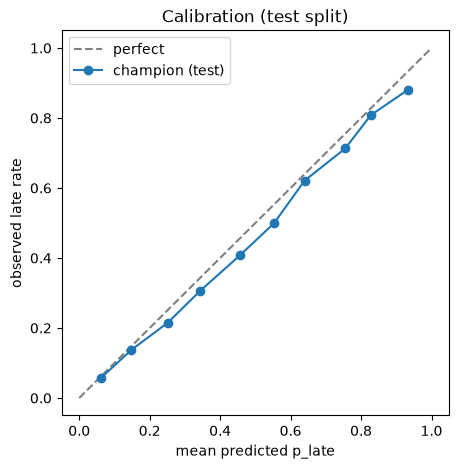

In [4]:
bins = pd.DataFrame([b.model_dump() for b in report.challenger_test.calibration])
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="perfect")
ax.plot(bins["mean_pred"], bins["observed_rate"], marker="o", label="champion (test)")
ax.set_xlabel("mean predicted p_late")
ax.set_ylabel("observed late rate")
ax.set_title("Calibration (test split)")
ax.legend()
plt.show()

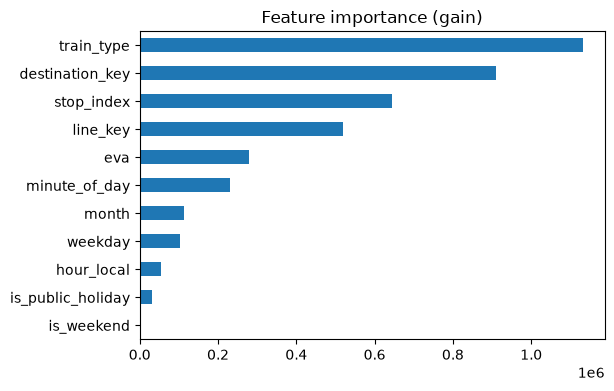

In [5]:
importance = json.loads(tracker.load_bytes(run_id, "feature_importance.json"))
gain = pd.Series(importance["gain"]).sort_values()
gain.plot.barh(figsize=(6, 4), title="Feature importance (gain)")
plt.show()